In [62]:
import pandas as pd
import sklearn
from sklearn.preprocessing import (
    MinMaxScaler,
    LabelEncoder,
    OrdinalEncoder,
    PolynomialFeatures,
    StandardScaler,
    
    
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer
import numpy as np
import seaborn as sns
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

In [7]:
df=pd.read_csv('drug200.csv')
df.head()

,Age,Sex,Cholesterol,Na_to_K,Drug,Group
0,23.0,F,HIGH,25.355,NaN,C
1,NaN,M,HIGH,13.093,drugC,A
2,47.0,M,HIGH,NaN,drugC,C
3,28.0,F,HIGH,7.798,drugX,C
4,61.0,F,HIGH,18.043,NaN,A


In [8]:
df['Drug'].value_counts()

Drug
DrugY    74
drugX    45
drugA    18
drugC    14
drugB     9
Name: count, dtype: int64

In [9]:
len(df)

200

In [10]:
df.dropna(subset=['Drug'],axis=0,inplace=True)

In [11]:
df.head()

,Age,Sex,Cholesterol,Na_to_K,Drug,Group
1,NaN,M,HIGH,13.093,drugC,A
2,47.0,M,HIGH,NaN,drugC,C
3,28.0,F,HIGH,7.798,drugX,C
5,22.0,F,HIGH,8.607,drugX,A
6,49.0,F,HIGH,16.275,DrugY,C


In [12]:
df.isnull().sum()

Age            36
Sex             0
Cholesterol     0
Na_to_K        32
Drug            0
Group          29
dtype: int64

<Axes: >

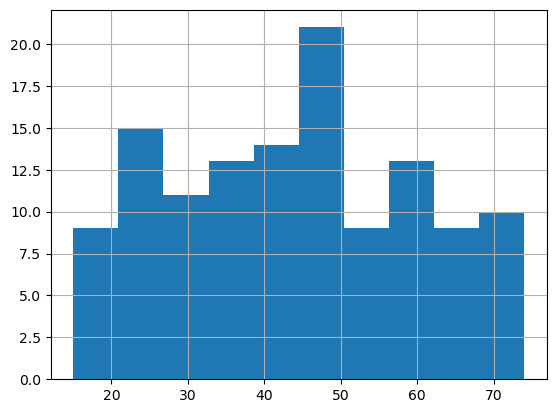

In [13]:
df['Age'].hist()

In [14]:
df['Sex']=df['Sex'].apply(lambda x: 1 if x=='M' else 0)

In [15]:
df.head()

,Age,Sex,Cholesterol,Na_to_K,Drug,Group
1,NaN,1,HIGH,13.093,drugC,A
2,47.0,1,HIGH,NaN,drugC,C
3,28.0,0,HIGH,7.798,drugX,C
5,22.0,0,HIGH,8.607,drugX,A
6,49.0,0,HIGH,16.275,DrugY,C


In [16]:
df['Cholesterol'].value_counts()

Cholesterol
NORMAL    81
HIGH      79
Name: count, dtype: int64

In [21]:
ordinal=OrdinalEncoder(categories=[['NORMAL','HIGH']],handle_unknown="use_encoded_value",
    unknown_value=np.nan,)

In [22]:
df[['Cholesterol']]=ordinal.fit_transform(df[['Cholesterol']])

In [23]:
df.head()

,Age,Sex,Cholesterol,Na_to_K,Drug,Group
1,NaN,1,1.0,13.093,drugC,A
2,47.0,1,1.0,NaN,drugC,C
3,28.0,0,1.0,7.798,drugX,C
5,22.0,0,1.0,8.607,drugX,A
6,49.0,0,1.0,16.275,DrugY,C


<Axes: >

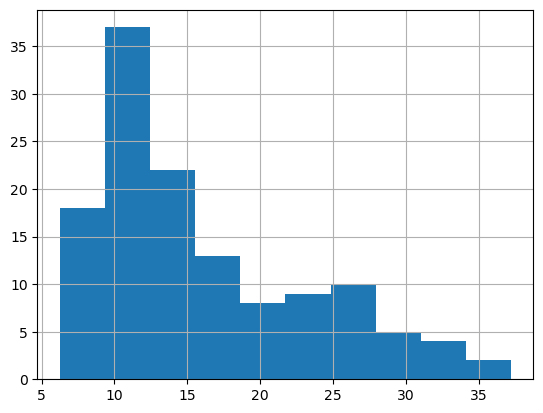

In [24]:
df['Na_to_K'].hist()

In [26]:
simple_imputer=SimpleImputer(strategy='median')

In [28]:
df[['Na_to_K']]=simple_imputer.fit_transform(df[['Na_to_K']])

In [29]:
df.isnull().sum()

Age            36
Sex             0
Cholesterol     0
Na_to_K         0
Drug            0
Group          29
dtype: int64

<Axes: xlabel='Group'>

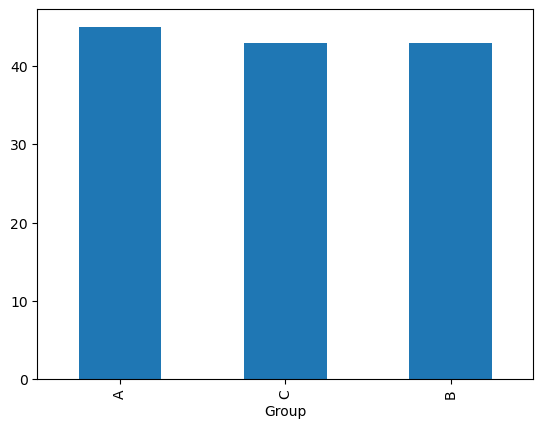

In [30]:
df['Group'].value_counts().plot.bar()

In [31]:
simple_imputer=SimpleImputer(strategy='mean')
df[['Age']]=simple_imputer.fit_transform(df[['Age']])

In [32]:
ordinal=OrdinalEncoder(categories='auto',handle_unknown="use_encoded_value",
    unknown_value=np.nan,)

In [33]:
df[['Group']]=ordinal.fit_transform(df[['Group']])

In [35]:
label_encoder=LabelEncoder()
df['Drug']=label_encoder.fit_transform(df['Drug'])

In [36]:
df.head()

,Age,Sex,Cholesterol,Na_to_K,Drug,Group
1,43.806452,1,1.0,13.0930,3,0.0
2,47.000000,1,1.0,13.8515,3,2.0
3,28.000000,0,1.0,7.7980,4,2.0
5,22.000000,0,1.0,8.6070,4,0.0
6,49.000000,0,1.0,16.2750,0,2.0


In [37]:
df.isnull().sum()

Age             0
Sex             0
Cholesterol     0
Na_to_K         0
Drug            0
Group          29
dtype: int64

<Axes: >

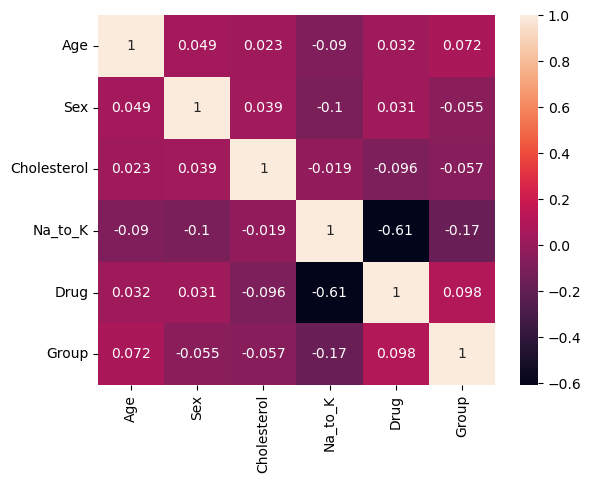

In [38]:
sns.heatmap(df.corr(),annot=True)

In [41]:
from sklearn.impute import KNNImputer

In [39]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df)

In [44]:
imputer = KNNImputer(n_neighbors=5)
imputed = imputer.fit_transform(scaled)

In [45]:
df = pd.DataFrame(scaler.inverse_transform(imputed), columns=df.columns)

In [46]:
X, y = df.drop(columns=["Drug"]), df["Drug"]

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2)

In [48]:
train_X = scaler.fit_transform(train_X)
test_X = scaler.transform(test_X)

In [52]:
classifier = LogisticRegression().fit(train_X, train_y)

In [53]:
y_pred=classifier.predict(test_X)

In [57]:
print(classification_report(test_y, y_pred))

              precision    recall  f1-score   support

         0.0       0.52      0.79      0.63        14
         1.0       0.00      0.00      0.00         2
         2.0       0.00      0.00      0.00         2
         3.0       0.00      0.00      0.00         6
         4.0       0.45      0.62      0.53         8

    accuracy                           0.50        32
   macro avg       0.20      0.28      0.23        32
weighted avg       0.34      0.50      0.41        32



C:\Users\dimit\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dimit\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dimit\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [58]:
df['Drug'].value_counts()

Drug
0.0    74
4.0    45
1.0    18
3.0    14
2.0     9
Name: count, dtype: int64

In [59]:
classifier = DecisionTreeClassifier().fit(train_X, train_y)

In [60]:
param_grid = {
    "criterion": ["entropy", "gini"],
    "max_depth": [None, 1, 2, 3, 4],
}

In [63]:
grid_search = GridSearchCV(
    classifier,
    param_grid,
    scoring="f1_weighted",
    cv=5,
)

In [64]:
grid_search.fit(train_X, train_y)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['entropy', 'gini'],
                         'max_depth': [None, 1, 2, 3, 4]},
             scoring='f1_weighted')

In [65]:
pred_y = grid_search.predict(test_X)

In [66]:
print(classification_report(test_y, pred_y))

              precision    recall  f1-score   support

         0.0       0.80      0.86      0.83        14
         1.0       0.00      0.00      0.00         2
         2.0       0.50      0.50      0.50         2
         3.0       0.67      0.33      0.44         6
         4.0       0.50      0.50      0.50         8

    accuracy                           0.59        32
   macro avg       0.49      0.44      0.45        32
weighted avg       0.63      0.59      0.60        32

